In [62]:
import pandas as pd
import pickle as pkl
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import root_mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import json

In [63]:
# get the training and validation data
with open('../data/processed/df_tabular_train.pkl', 'rb') as f:
    df_train = pkl.load(f)

with open('../data/processed/df_tabular_validate.pkl', 'rb') as f:
    df_validate = pkl.load(f)

In [64]:
# seperate into features and target
X_train = df_train.drop(columns=['hourly_usage_kwh'])
X_validate = df_validate.drop(columns=['hourly_usage_kwh'])

y_train = df_train['hourly_usage_kwh']
y_validate = df_validate['hourly_usage_kwh']

In [ ]:
# condition number indicative of multicolinearity
np.linalg.cond(X_train)

np.float64(50.54791070917731)

In [132]:
# need to standardise each feature in per client basis
rgr_OLS = LinearRegression()
rgr_Lasso = Lasso(alpha=0.1)
rgr_Ridge = Ridge()

In [133]:
# fit the models
rgr_OLS.fit(X_train, y_train)
rgr_Ridge.fit(X_train, y_train)
rgr_Lasso.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [149]:
# quick evaluation

with open('../data/processed/df_tabular_test.pkl', 'rb') as f:
    df_test = pkl.load(f)

X_test = df_test.drop(columns=['hourly_usage_kwh'])
y_test = df_test['hourly_usage_kwh']

In [150]:
# load in mean and std usages for converting labels and predictions back to original units and for nrmse
# computation
with open('../data/processed/mean_std_per_client.json', 'r') as f:
    df_std_mean_usage = pd.read_json(f).T
    dict_std_mean_usage = df_std_mean_usage.to_dict(orient='index')

In [151]:
# get predictions
y_pred_OLS = rgr_OLS.predict(X_test)
y_pred_Lasso = rgr_Lasso.predict(X_test)
y_pred_Ridge = rgr_Ridge.predict(X_test)

In [152]:
def unscale_per_client(group, dict_with_mean_and_std):
    """ use mean and std usage for each client to unscale data, ready for 
    evaluation """

    client_id = int(np.unique(group.index.get_level_values('client_id'))[0])

    return ((group * dict_with_mean_and_std[client_id]['std']) + dict_with_mean_and_std[client_id]['mean'])

In [153]:
# create frame from client ids and predictions
df_preds = pd.DataFrame(index=df_test.index, data={'y_pred_OLS': y_pred_OLS,
                                                   'y_pred_Lasso': y_pred_Lasso,
                                                   'y_pred_Ridge': y_pred_Ridge,
                                                      'y_true': y_test})

In [154]:
# now unscale the predictions to get original units
df_preds_unscaled = df_preds.groupby(level='client_id').transform(lambda g: unscale_per_client(g, dict_std_mean_usage))

In [155]:
# for each client compute the rmse
rmse_per_client_OLS = df_preds_unscaled.groupby(level='client_id').apply(lambda g: root_mean_squared_error(g['y_true'], g['y_pred_OLS']))
rmse_per_client_Lasso = df_preds_unscaled.groupby(level='client_id').apply(lambda g: root_mean_squared_error(g['y_true'], g['y_pred_Lasso']))
rmse_per_client_Ridge = df_preds_unscaled.groupby(level='client_id').apply(lambda g: root_mean_squared_error(g['y_true'], g['y_pred_Ridge']))

In [156]:
# get the mean normalised
nrmse_per_client_OLS = rmse_per_client_OLS/df_std_mean_usage['mean']
nrmse_per_client_Lasso = rmse_per_client_Lasso/df_std_mean_usage['mean']
nrmse_per_client_Ridge = rmse_per_client_Ridge/df_std_mean_usage['mean']

In [157]:
summary_dict_OLS = {
                'mean': nrmse_per_client_OLS.mean(),
                'std': nrmse_per_client_OLS.std(),
                'max': nrmse_per_client_OLS.max(),
                'min': nrmse_per_client_OLS.min(),
                }

summary_dict_Lasso = {
                'mean': nrmse_per_client_Lasso.mean(),
                'std': nrmse_per_client_Lasso.std(),
                'max': nrmse_per_client_Lasso.max(),
                'min': nrmse_per_client_Lasso.min(),
                }

summary_dict_Ridge = {
                'mean': nrmse_per_client_Ridge.mean(),
                'std': nrmse_per_client_Ridge.std(),
                'max': nrmse_per_client_Ridge.max(),
                'min': nrmse_per_client_Ridge.min(),
                }

In [158]:
print(summary_dict_OLS['mean'])
print(summary_dict_Lasso['mean'])
print(summary_dict_Ridge['mean'])

0.1018280756723432
0.11559828137731881
0.10182806663800582


In [159]:
lasso_coeffs = rgr_Lasso.coef_
ridge_coeffs = rgr_Ridge.coef_
OLS_coeffs = rgr_OLS.coef_

feature_names = X_train.columns

df_coeffs = pd.DataFrame(data={'feature': feature_names,
                                'Lasso': lasso_coeffs, 
                                'Ridge': ridge_coeffs, 
                               'OLS': OLS_coeffs})

df_coeffs.head(50)

,feature,Lasso,Ridge,OLS
0,hour_sin,-0.000000,-0.010554,-0.010554
1,hour_cos,-0.000000,-0.061016,-0.061016
2,day_sin,0.000000,0.009428,0.009428
3,day_cos,-0.000000,0.008169,0.008169
4,month_sin,-0.000000,0.002694,0.002694
5,month_cos,-0.000000,-0.007667,-0.007667
6,lag_1hr,0.388145,0.562247,0.562249
7,lag_2hr,0.000000,-0.121070,-0.121072
8,lag_6hr,-0.000000,-0.028327,-0.028327
9,lag_1dy,0.230368,0.212091,0.212090


In [160]:
# log the results 

# and log these, along with dataframe of predicitons

with open('../logs/linReg/nrmse_summary_stats_OLS.json', 'w') as f:
    json.dump(summary_dict_OLS, f, indent=4)

with open('../logs/linReg/nrmse_summary_stats_Lasso.json', 'w') as f:
    json.dump(summary_dict_Lasso, f, indent=4)

with open('../logs/linReg/nrmse_summary_stats_Ridge.json', 'w') as f:
    json.dump(summary_dict_Ridge, f, indent=4)

with open('../logs/linReg/nrmse_per_client_OLS.json', 'w') as f:
    json.dump(nrmse_per_client_OLS.to_list(), f, indent=4)

with open('../logs/linReg/nrmse_per_client_Lasso.json', 'w') as f:
    json.dump(nrmse_per_client_Lasso.to_list(), f, indent=4)

with open('../logs/linReg/nrmse_per_client_Ridge.json', 'w') as f:
    json.dump(nrmse_per_client_Ridge.to_list(), f, indent=4)

# save the XGB model used
with open('../models/OLS.pkl', 'wb') as f:
    pkl.dump(rgr_OLS, f)

with open('../models/Lasso.pkl', 'wb') as f:
    pkl.dump(rgr_Lasso, f)

with open('../models/Ridge.pkl', 'wb') as f:
    pkl.dump(rgr_Ridge, f)

# save predictions and labels for further evaluation (also gives client ids used)
df_preds.to_csv('../data/processed/linRegModels_preds_labels.csv')

In [165]:
# now for simple plot check
import matplotlib.pyplot as plt

client = 370

df_preds_filtered = df_preds_unscaled[df_preds_unscaled.index.get_level_values('client_id') == client].iloc[0:128*4]

df_preds_filtered.head()

# where did the datetimes go?

datetimes = pd.to_datetime(df_preds_filtered.index.get_level_values('datetime'))
preds_OLS = df_preds_filtered['y_pred_OLS']
preds_Lasso = df_preds_filtered['y_pred_Lasso']
preds_Ridge = df_preds_filtered['y_pred_Ridge']
labels = df_preds_filtered['y_true']

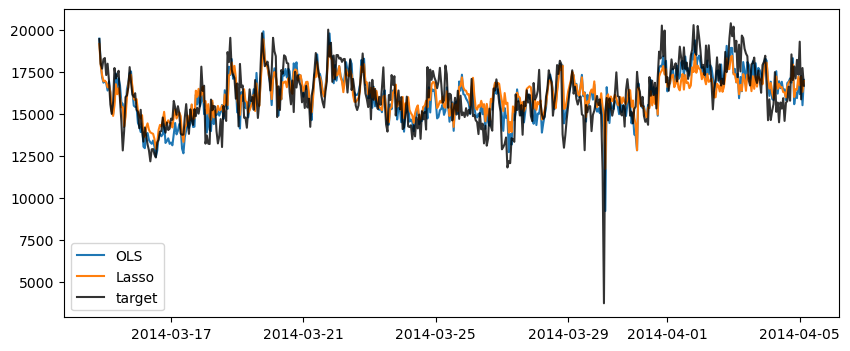

In [166]:
plt.figure(figsize=(10, 4))
plt.plot(datetimes, preds_OLS, label='OLS')
plt.plot(datetimes, preds_Lasso, label='Lasso')
# plt.plot(datetimes, preds_Ridge, label='Ridge')
plt.plot(datetimes, labels, label='target', color='black', alpha=0.8)
plt.legend()
plt.show()